# 13 — Final checks, final figures, final bundle

Everything left before the manuscript's last rebuild, in run order:

1. **2018 duplicate audit** (completes the audit symmetry with 2017).
2. **Display of all remaining result tables** so every number is on record.
3. **Revised Fig. 1** — the pipeline, now annotated for both benchmarks + D6.
4. **New Fig. 7** — per-class recall collapse and the flagged-share result
   (replaces the old Fig. 4 in the manuscript).
5. **Exhibit checklist** — every file the final manuscript depends on.
6. **paper_bundle_v2 zip** — one download containing all of it.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
DRIVE_ROOT = '/content/drive/MyDrive/research/ids-label-correction'
sys.path.insert(0, os.path.join(DRIVE_ROOT, 'src'))

import importlib, config as C, helpers as H
importlib.reload(C); importlib.reload(H)
import pandas as pd, numpy as np, json
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
# ---- 1) 2018 duplicate audit (hash-based, corpus-wide per version) ----------
RAW18 = os.path.join(DRIVE_ROOT, 'data/raw_original_2018')
OUT_J = os.path.join(C.RESULTS, 't18_duplicates.json')

if os.path.exists(OUT_J):
    print('already computed:', json.load(open(OUT_J)))
else:
    def corpus_dups(file_iter, reader, tag):
        hashes = []
        for name, path in file_iter:
            df = reader(path)
            hashes.append(pd.util.hash_pandas_object(df, index=False))
            print(f'{tag} {name:55s} {len(df):>10,}')
            del df
        allh = pd.concat(hashes, ignore_index=True)
        d = int(allh.duplicated().sum())
        print(f'{tag}: {len(allh):,} rows, {d:,} duplicate rows '
              f'({100*d/len(allh):.3f}%)  [hash-based]\n')
        return len(allh), d

    def read_o(p):
        df = pd.read_csv(p, low_memory=False, encoding='latin-1', dtype=str)
        df = H.harmonise(df)
        return df[df['label'].notna() & (df['label'] != 'Label')]

    def read_i(p):
        return H.harmonise(pd.read_csv(p, low_memory=False, dtype=str))

    ofiles = [(f, os.path.join(RAW18, f))
              for f in sorted(os.listdir(RAW18)) if f.endswith('.csv')]
    ifiles = []
    for dp, _, fs in os.walk(C.RAW_IMPROVED):
        for f in sorted(fs):
            if f.lower().endswith('.csv') and '2018' in f:
                ifiles.append((f, os.path.join(dp, f)))

    no, do = corpus_dups(ofiles, read_o, 'original')
    ni, di = corpus_dups(ifiles, read_i, 'improved')
    json.dump({'original_rows': no, 'original_duplicates': do,
               'original_dup_pct': round(100*do/no, 3),
               'improved_rows': ni, 'improved_duplicates': di,
               'improved_dup_pct': round(100*di/ni, 3),
               'method': 'pandas row-hash, corpus-wide within version'},
              open(OUT_J, 'w'), indent=2)
    print('saved', OUT_J)

original Friday-02-03-2018_TrafficForML_CICFlowMeter.csv          1,048,575
original Friday-16-02-2018_TrafficForML_CICFlowMeter.csv          1,048,574
original Friday-23-02-2018_TrafficForML_CICFlowMeter.csv          1,048,575
original Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv        7,948,748
original Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv          331,100
original Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv        1,048,575
original Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv        1,048,575
original Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv       1,048,575
original Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv       1,048,575
original Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv         613,071
original: 16,232,943 rows, 410,707 duplicate rows (2.530%)  [hash-based]

improved Friday-02-03-2018.csv                                    6,311,371
improved Friday-16-02-2018.csv                                    7,390,266
improved Frida

In [3]:
# ---- 2) Every remaining result table, on record -----------------------------
def show(name, kind='csv'):
    p = os.path.join(C.RESULTS, name)
    if not os.path.exists(p):
        print('MISSING:', name); return
    print('=' * 70); print(name)
    if kind == 'csv':
        df = pd.read_csv(p)
        print(df.to_string(index=False))
    else:
        print(json.dumps(json.load(open(p)), indent=2))

show('t12_key_sensitivity.csv')
show('t12_duration_stability.csv')
show('t11_common_test.csv')
show('t11_pred_disagreement.csv')
show('t11_perclass.csv')
show('t11_bootstrap_ci.csv')
show('t18_duplicates.json', 'json')
show('t18_match_summary.json', 'json')
show('cross_dataset_headline.json', 'json')

t12_key_sensitivity.csv
  variant  unique_original  unique_improved  matched  pct_of_unique_original  family_disagree_pct  benign_to_attack
canonical          1767843          2073720  1604995                   90.79               4.0505             65001
 directed          2218218          2074039  1797981                   81.06               3.1762             57095
t12_duration_stability.csv
 duration_tolerance_s   pairs  pct_of_matched  family_disagree_pct
                  0.1 1472677           91.76               4.0352
                  1.0 1509849           94.07               4.1745
                  5.0 1521296           94.79               4.2495
                  inf 1604995          100.00               4.0505
t11_common_test.csv
        model trained_on scored_against  macro_f1_family  binary_attack_recall  binary_attack_precision
       logreg   original       improved           0.6525                0.8805                   0.9922
       logreg   original       origina

saved (revised) /content/drive/MyDrive/research/ids-label-correction/figures/fig0_pipeline.png


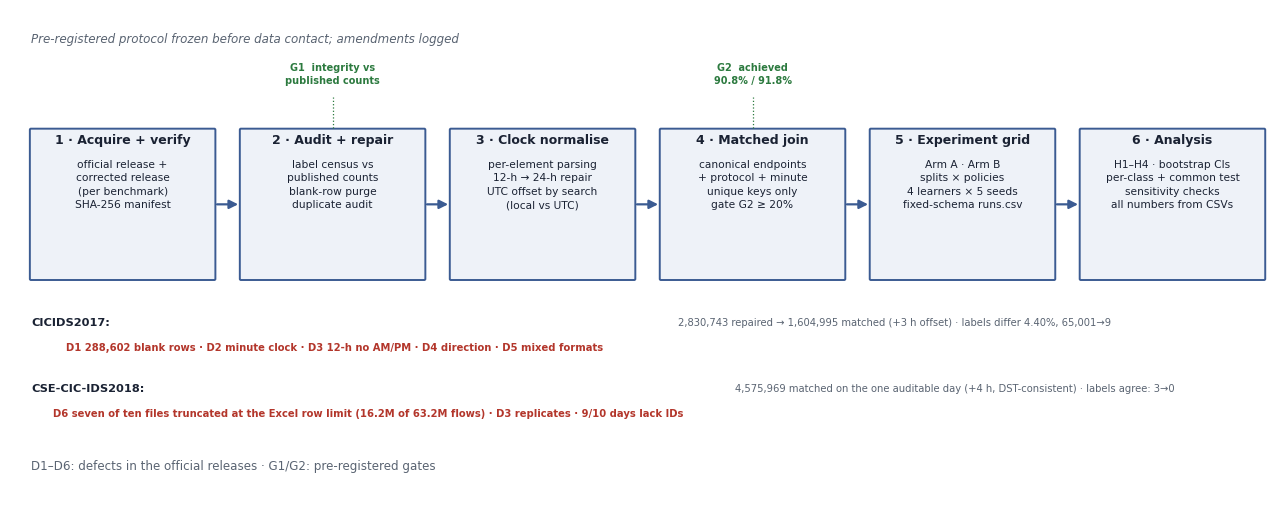

In [4]:
# ---- 3) Revised Fig. 1: pipeline annotated for BOTH benchmarks + D6 ---------
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK, BOX, EDGE = '#1a2233', '#eef2f8', '#3b5b92'
RED, GREEN, GREY = '#b3362b', '#2c7a3f', '#5a6472'

def box(ax, x, y, w, h, title, lines, fc=BOX, ec=EDGE, fs=8.3):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012",
                                fc=fc, ec=ec, lw=1.4))
    ax.text(x+w/2, y+h-0.045, title, ha='center', va='top',
            fontsize=fs+0.7, fontweight='bold', color=INK)
    ax.text(x+w/2, y+h-0.315, '\n'.join(lines), ha='center', va='top',
            fontsize=fs-0.6, color=INK, linespacing=1.45)

def arrow(ax, x1, y1, x2, y2, color=EDGE):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                                 mutation_scale=13, color=color, lw=1.6))

def tag(ax, x, y, text, color, fs=7.0):
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, color=color,
            fontweight='bold', linespacing=1.35)

fig, ax = plt.subplots(figsize=(13.2, 5.3))
ax.set_xlim(0, 13.2); ax.set_ylim(0, 5.3); ax.axis('off')
W, Hh, Y = 1.92, 1.58, 2.45
xs = [0.22, 2.42, 4.62, 6.82, 9.02, 11.22]

box(ax, xs[0], Y, W, Hh, '1 \u00b7 Acquire + verify',
    ['official release +', 'corrected release', '(per benchmark)',
     'SHA-256 manifest'])
box(ax, xs[1], Y, W, Hh, '2 \u00b7 Audit + repair',
    ['label census vs', 'published counts', 'blank-row purge',
     'duplicate audit'])
box(ax, xs[2], Y, W, Hh, '3 \u00b7 Clock normalise',
    ['per-element parsing', '12-h \u2192 24-h repair',
     'UTC offset by search', '(local vs UTC)'])
box(ax, xs[3], Y, W, Hh, '4 \u00b7 Matched join',
    ['canonical endpoints', '+ protocol + minute',
     'unique keys only', 'gate G2 \u2265 20%'])
box(ax, xs[4], Y, W, Hh, '5 \u00b7 Experiment grid',
    ['Arm A \u00b7 Arm B', 'splits \u00d7 policies',
     '4 learners \u00d7 5 seeds', 'fixed-schema runs.csv'])
box(ax, xs[5], Y, W, Hh, '6 \u00b7 Analysis',
    ['H1\u2013H4 \u00b7 bootstrap CIs', 'per-class + common test',
     'sensitivity checks', 'all numbers from CSVs'])
for i in range(5):
    arrow(ax, xs[i]+W, Y+Hh/2, xs[i+1], Y+Hh/2)

tag(ax, xs[1]+W/2, 4.62, 'G1  integrity vs\npublished counts', GREEN)
tag(ax, xs[3]+W/2, 4.62, 'G2  achieved\n90.8% / 91.8%', GREEN)
for xc in (xs[1]+W/2, xs[3]+W/2):
    ax.plot([xc, xc], [Y+Hh+0.02, 4.38], color=GREEN, lw=0.9, ls=':')

# benchmark strips
ax.text(0.22, 1.95, 'CICIDS2017:', fontsize=8.2, color=INK, fontweight='bold')
tag(ax, 3.4, 1.72, 'D1 288,602 blank rows \u00b7 D2 minute clock \u00b7 '
    'D3 12-h no AM/PM \u00b7 D4 direction \u00b7 D5 mixed formats', RED, 7.2)
ax.text(7.0, 1.95, '2,830,743 repaired \u2192 1,604,995 matched (+3 h offset) '
        '\u00b7 labels differ 4.40%, 65,001\u21929', fontsize=7.2, color=GREY)

ax.text(0.22, 1.25, 'CSE-CIC-IDS2018:', fontsize=8.2, color=INK,
        fontweight='bold')
tag(ax, 3.75, 1.02, 'D6 seven of ten files truncated at the Excel row limit '
    '(16.2M of 63.2M flows) \u00b7 D3 replicates \u00b7 9/10 days lack IDs', RED, 7.2)
ax.text(7.6, 1.25, '4,575,969 matched on the one auditable day (+4 h, '
        'DST-consistent) \u00b7 labels agree: 3\u21920', fontsize=7.2, color=GREY)

ax.text(0.22, 4.95, 'Pre-registered protocol frozen before data contact; '
        'amendments logged', fontsize=8.6, color=GREY, style='italic')
ax.text(0.22, 0.42, 'D1\u2013D6: defects in the official releases \u00b7 '
        'G1/G2: pre-registered gates', fontsize=8.6, color=GREY)

fig.tight_layout()
p = os.path.join(C.FIGURES, 'fig0_pipeline.png')
fig.savefig(p, dpi=220, bbox_inches='tight')
print('saved (revised)', p)
plt.show()

saved /content/drive/MyDrive/research/ids-label-correction/figures/fig7_perclass_flagging.png


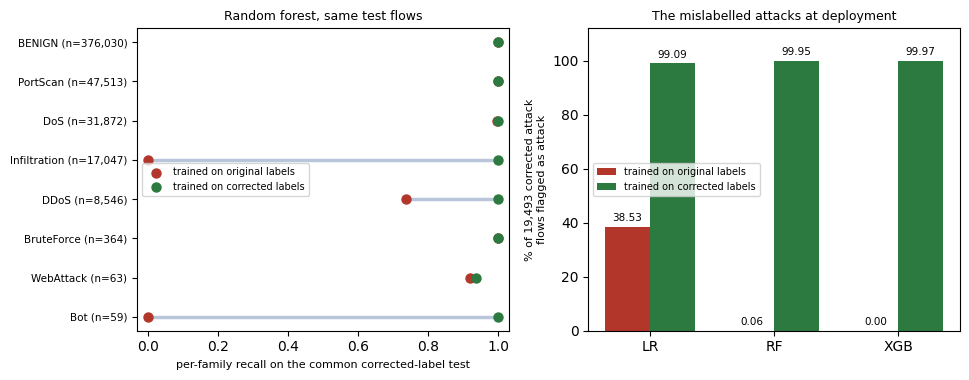

In [5]:
# ---- 4) NEW Fig. 7: per-class collapse + flagged-share ----------------------
pc = pd.read_csv(os.path.join(C.RESULTS, 't11_perclass.csv'))
pdis = pd.read_csv(os.path.join(C.RESULTS, 't11_pred_disagreement.csv'))

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))

# Panel A: per-class recall dumbbells (random forest), families with n>=50
ax = axes[0]
d = pc[pc['n_test'] >= 50].sort_values('n_test')
y = np.arange(len(d))
ax.hlines(y, d['random_forest_original_recall'],
          d['random_forest_improved_recall'], color='#b9c6da', lw=2.5, zorder=1)
ax.scatter(d['random_forest_original_recall'], y, s=42, color='#b3362b',
           zorder=2, label='trained on original labels')
ax.scatter(d['random_forest_improved_recall'], y, s=42, color='#2c7a3f',
           zorder=2, label='trained on corrected labels')
ax.set_yticks(y)
ax.set_yticklabels([f"{r['family']} (n={r['n_test']:,})"
                    for _, r in d.iterrows()], fontsize=7.5)
ax.set_xlabel('per-family recall on the common corrected-label test',
              fontsize=8)
ax.set_xlim(-0.03, 1.03)
ax.set_title('Random forest, same test flows', fontsize=9)
ax.legend(fontsize=7, loc='center left')

# Panel B: share of the benign->attack corrected flows flagged as attack
ax = axes[1]
n_b2a = int(pdis['b2a_flows_in_test'].iloc[0])
x = np.arange(len(pdis)); w = 0.36
labels = pdis['model'].str.replace('random_forest', 'RF') \
                      .str.replace('logreg', 'LR').str.replace('xgboost', 'XGB')
ax.bar(x - w/2, pdis['orig_model_flags_pct'], w, color='#b3362b',
       label='trained on original labels')
ax.bar(x + w/2, pdis['corr_model_flags_pct'], w, color='#2c7a3f',
       label='trained on corrected labels')
for xi, v in zip(x - w/2, pdis['orig_model_flags_pct']):
    ax.text(xi, v + 2, f'{v:.2f}', ha='center', fontsize=7.5)
for xi, v in zip(x + w/2, pdis['corr_model_flags_pct']):
    ax.text(xi, min(v + 2, 104), f'{v:.2f}', ha='center', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 112)
ax.set_ylabel(f'% of {n_b2a:,} corrected attack\nflows flagged as attack',
              fontsize=8)
ax.set_title('The mislabelled attacks at deployment', fontsize=9)
ax.legend(fontsize=7)

fig.tight_layout()
p = os.path.join(C.FIGURES, 'fig7_perclass_flagging.png')
fig.savefig(p, dpi=220, bbox_inches='tight')
print('saved', p)
plt.show()

In [6]:
# ---- 5) Exhibit checklist ----------------------------------------------------
REQUIRED = [
 # 2017 core
 'results/runs.csv', 'results/headline.json', 'results/h1_dataset_level.csv',
 'results/h2_label_isolation.csv', 'results/h3_attempted_sensitivity.csv',
 'results/h4_equivalence.csv', 'results/binary_headline.csv',
 'results/matched_representativeness.csv', 'results/appendix_degenerate_runs.csv',
 'results/table1_class_census.csv', 'results/table2_duplicates.csv',
 'results/table5_label_transition_matrix.csv', 'results/table6_match_summary.csv',
 'results/table7_relabel_rate_per_class.csv', 'results/table0_file_reconciliation.csv',
 'results/match_calibration.json', 'results/gate_g1.json', 'results/repair_log.json',
 # 2018 replication
 'results/t18_original_files.csv', 'results/t18_class_census.csv',
 'results/t18_transition_matrix.csv', 'results/t18_match_summary.json',
 'results/t18_changed_decomposition.csv', 'results/t18_duplicates.json',
 # cross-dataset + robustness + consequence
 'results/cross_dataset_headline.json', 'results/cross_dataset_table.csv',
 'results/t11_common_test.csv', 'results/t11_pred_disagreement.csv',
 'results/t11_perclass.csv', 'results/t11_bootstrap_ci.csv',
 'results/t11_attempted_third_class.csv',
 'results/t12_key_sensitivity.csv', 'results/t12_duration_stability.csv',
 # figures (fig1_arm_a_vs_b retired from the manuscript, kept in archive)
 'figures/fig0_pipeline.png', 'figures/fig0b_design.png',
 'figures/fig2_unseen_family_recall.png', 'figures/fig3_transition_heatmap.png',
 'figures/fig6_cross_dataset.png', 'figures/fig7_perclass_flagging.png',
 'PROTOCOL_AMENDMENTS.md',
]
os.chdir(DRIVE_ROOT)
missing = [p for p in REQUIRED if not os.path.exists(p)]
for p in REQUIRED:
    print(('OK   ' if os.path.exists(p) else 'MISS ') + p)
print(f'\n{"ALL PRESENT" if not missing else str(len(missing)) + " MISSING"}')

OK   results/runs.csv
OK   results/headline.json
OK   results/h1_dataset_level.csv
OK   results/h2_label_isolation.csv
OK   results/h3_attempted_sensitivity.csv
OK   results/h4_equivalence.csv
OK   results/binary_headline.csv
OK   results/matched_representativeness.csv
OK   results/appendix_degenerate_runs.csv
OK   results/table1_class_census.csv
OK   results/table2_duplicates.csv
OK   results/table5_label_transition_matrix.csv
OK   results/table6_match_summary.csv
OK   results/table7_relabel_rate_per_class.csv
OK   results/table0_file_reconciliation.csv
OK   results/match_calibration.json
OK   results/gate_g1.json
OK   results/repair_log.json
OK   results/t18_original_files.csv
OK   results/t18_class_census.csv
OK   results/t18_transition_matrix.csv
OK   results/t18_match_summary.json
OK   results/t18_changed_decomposition.csv
OK   results/t18_duplicates.json
OK   results/cross_dataset_headline.json
OK   results/cross_dataset_table.csv
OK   results/t11_common_test.csv
OK   results/t11

In [7]:
# ---- 6) paper_bundle_v2 ------------------------------------------------------
import hashlib, zipfile, shutil
from datetime import date

def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

rows = []
for d in ['results', 'figures', 'src']:
    for fn in sorted(os.listdir(d)):
        p = os.path.join(d, fn)
        if os.path.isfile(p):
            rows.append({'path': p, 'bytes': os.path.getsize(p),
                         'sha256': sha256(p)})
for f in ['PROTOCOL.md', 'PROTOCOL_AMENDMENTS.md', 'make_diagrams.py']:
    if os.path.isfile(f):
        rows.append({'path': f, 'bytes': os.path.getsize(f), 'sha256': sha256(f)})
man = pd.DataFrame(rows)
man.to_csv('MANIFEST.csv', index=False)
print(f'MANIFEST.csv: {len(man)} files, {man["bytes"].sum()/1e6:.1f} MB')

stamp = date.today().strftime('%Y%m%d')
zpath = f'/content/paper_bundle_v2_{stamp}.zip'
with zipfile.ZipFile(zpath, 'w', zipfile.ZIP_DEFLATED) as z:
    for d in ['results', 'figures', 'src']:
        for fn in sorted(os.listdir(d)):
            p = os.path.join(d, fn)
            if os.path.isfile(p):
                z.write(p)
    for f in ['PROTOCOL.md', 'PROTOCOL_AMENDMENTS.md', 'make_diagrams.py',
              'MANIFEST.csv']:
        if os.path.isfile(f):
            z.write(f)
print(zpath, f'{os.path.getsize(zpath)/1e6:.1f} MB')

from google.colab import files
files.download(zpath)

MANIFEST.csv: 51 files, 1.3 MB
/content/paper_bundle_v2_20260823.zip 1.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>